# 03 - Comprehensive Experiments

Runs the complete experimental suite:
E1: Synthetic datasets (5 methods)
E2: UCI benchmarks (Iris, Wine, Breast Cancer)
E3: Ablation study
E4: Parameter robustness
E5: High-dimensional robustness
E6: Runtime comparison

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns
import time, warnings, os; warnings.filterwarnings("ignore")
from src.svc import SVC
from src.asvc import ASVC
from src.utils import *
from src.parameter_selection import adaptive_q_search, compute_C_from_nu
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.decomposition import PCA
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
np.random.seed(42)
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)
print("Ready.")

Ready.


## E1: Synthetic Datasets

In [2]:
def run_comp(X, y_true):
    k = len(np.unique(y_true)); results = {}
    for name, fn in [
        ("K-Means", lambda: KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)),
        ("DBSCAN", lambda: DBSCAN(eps=0.3, min_samples=5).fit_predict(X)),
        ("Spectral", lambda: SpectralClustering(n_clusters=k, affinity="rbf", random_state=42).fit_predict(X)),
        ("SVC", lambda: SVC(q=4.5, C=1.0, n_sample_points=30).fit_predict(X)),
        ("ASVC", lambda: ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit_predict(X)),
    ]:
        try: results[name] = clustering_metrics(y_true, fn())
        except: results[name] = {"ARI": 0, "NMI": 0}
    return results

datasets = generate_synthetic_datasets()
all_r = {}
for name in ["TwoMoons", "ConcentricCircles", "ThreeBlobs", "OverlappingGaussians", "VaryingBlobs", "TwoMoonsNoisy"]:
    X, y = datasets[name]
    print(f"Running {name}...")
    all_r[name] = run_comp(X, y)

rows = []
for ds, methods in all_r.items():
    for m, met in methods.items():
        row = {"Dataset": ds, "Method": m}
        for k in ["ARI", "NMI"]: row[k] = f"{met.get(k, 0):.4f}"
        rows.append(row)
df = pd.DataFrame(rows)
print("\n=== Synthetic Results ===")
print(df.to_string(index=False))


Running TwoMoons...
Running ConcentricCircles...
Running ThreeBlobs...
Running OverlappingGaussians...
Running VaryingBlobs...
Running TwoMoonsNoisy...

=== Synthetic Results ===
             Dataset   Method     ARI    NMI
            TwoMoons  K-Means  0.4790 0.3819
            TwoMoons   DBSCAN  1.0000 1.0000
            TwoMoons Spectral  0.5168 0.4159
            TwoMoons      SVC  1.0000 1.0000
            TwoMoons     ASVC  0.4284 0.6040
   ConcentricCircles  K-Means -0.0033 0.0000
   ConcentricCircles   DBSCAN  0.9615 0.9429
   ConcentricCircles Spectral -0.0032 0.0001
   ConcentricCircles      SVC  1.0000 1.0000
   ConcentricCircles     ASVC  0.7111 0.7035
          ThreeBlobs  K-Means  1.0000 1.0000
          ThreeBlobs   DBSCAN  0.9950 0.9916
          ThreeBlobs Spectral  1.0000 1.0000
          ThreeBlobs      SVC  1.0000 1.0000
          ThreeBlobs     ASVC  0.9850 0.9752
OverlappingGaussians  K-Means  1.0000 1.0000
OverlappingGaussians   DBSCAN  0.9649 0.9402
Overlapping

## E2: UCI Benchmarks

In [3]:
def run_uci(X, y, n_pca=None):
    if n_pca: X = standardize(PCA(n_components=n_pca).fit_transform(X))
    k = len(np.unique(y)); r = {}
    for m, fn in [
        ("K-Means", lambda: KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)),
        ("DBSCAN", lambda: DBSCAN(eps=0.5, min_samples=5).fit_predict(X)),
        ("Spectral", lambda: SpectralClustering(n_clusters=k, affinity="rbf", random_state=42).fit_predict(X)),
        ("SVC", lambda: SVC(q=3.0, C=0.5, n_sample_points=30).fit_predict(X)),
        ("ASVC", lambda: ASVC(nu=0.2, q="auto", q_search_n_trials=10, random_state=42).fit_predict(X)),
    ]:
        try: r[m] = clustering_metrics(y, fn())
        except Exception as e: print(f"  {m} failed: {e}")
    return r

X_ir, y_ir, _ = load_uci_iris()
r_ir = run_uci(X_ir, y_ir, n_pca=2)
X_wi, y_wi, _ = load_uci_wine(); r_wi = run_uci(X_wi, y_wi)
X_bc, y_bc, _ = load_uci_breast_cancer(); r_bc = run_uci(X_bc, y_bc, n_pca=5)

rows2 = []
for ds, rr in [("Iris", r_ir), ("Wine", r_wi), ("BreastCancer", r_bc)]:
    for m, met in rr.items():
        row = {"Dataset": ds, "Method": m}
        for k in ["ARI", "NMI", "Homogeneity", "Completeness"]:
            row[k] = f"{met.get(k, 0):.4f}"
        rows2.append(row)
df2 = pd.DataFrame(rows2)
print("\n=== UCI Results ===")
print(df2.to_string(index=False))



=== UCI Results ===
     Dataset   Method     ARI    NMI Homogeneity Completeness
        Iris  K-Means  0.5803 0.6162      0.6161       0.6163
        Iris   DBSCAN  0.5379 0.6547      0.5595       0.7891
        Iris Spectral  0.5520 0.6026      0.5986       0.6067
        Iris      SVC  0.5492 0.6915      0.5963       0.8229
        Iris     ASVC  0.4301 0.5682      0.6234       0.5219
        Wine  K-Means  0.8975 0.8759      0.8788       0.8730
        Wine   DBSCAN  0.0000 0.0000      0.0000       1.0000
        Wine Spectral  0.4446 0.5725      0.4689       0.7348
        Wine      SVC  0.0000 0.3465      1.0000       0.2096
        Wine     ASVC -0.0097 0.0500      0.0293       0.1684
BreastCancer  K-Means  0.7856 0.7068      0.6902       0.7241
BreastCancer   DBSCAN -0.0604 0.1271      0.1383       0.1176
BreastCancer Spectral  0.0048 0.0102      0.0053       0.1489
BreastCancer      SVC  0.0942 0.1648      0.3210       0.1109
BreastCancer     ASVC  0.0307 0.0961      0.0862 

## E3: Ablation Study on Iris 2D

=== Ablation Study ===
Full ASVC (auto q + spectral):  ARI = 0.5394
w/o Spectral (auto q + sampling): ARI = 0.4390
w/o Adaptive (fixed q + spectral): ARI = 0.5394


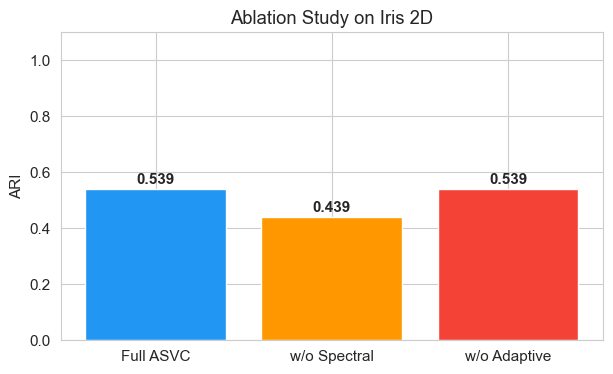

In [4]:
X_ir2d = standardize(PCA(n_components=2).fit_transform(X_ir))
asvc_full = ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit(X_ir2d)
ari_full = clustering_metrics(y_ir, asvc_full.labels_)["ARI"]

best_q, _ = adaptive_q_search(X_ir2d, nu=0.02, n_trials=10)
C_auto = compute_C_from_nu(0.3, len(X_ir2d))
svc_adaptive = SVC(q=best_q, C=C_auto, n_sample_points=30).fit(X_ir2d)
ari_nospec = clustering_metrics(y_ir, svc_adaptive.labels_)["ARI"]

asvc_fixed = ASVC(nu=0.02, q=4.0, random_state=42).fit(X_ir2d)
ari_noadapt = clustering_metrics(y_ir, asvc_fixed.labels_)["ARI"]

print("=== Ablation Study ===")
print(f"Full ASVC (auto q + spectral):  ARI = {ari_full:.4f}")
print(f"w/o Spectral (auto q + sampling): ARI = {ari_nospec:.4f}")
print(f"w/o Adaptive (fixed q + spectral): ARI = {ari_noadapt:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Full ASVC", "w/o Spectral", "w/o Adaptive"],
             [ari_full, ari_nospec, ari_noadapt],
             color=["#2196F3", "#FF9800", "#F44336"])
for bar, val in zip(bars, [ari_full, ari_nospec, ari_noadapt]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{val:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("ARI"); ax.set_title("Ablation Study on Iris 2D"); ax.set_ylim(0, 1.1)
plt.savefig("../results/figures/ablation.png", dpi=150, bbox_inches="tight")
plt.show()


## E4: Parameter Robustness

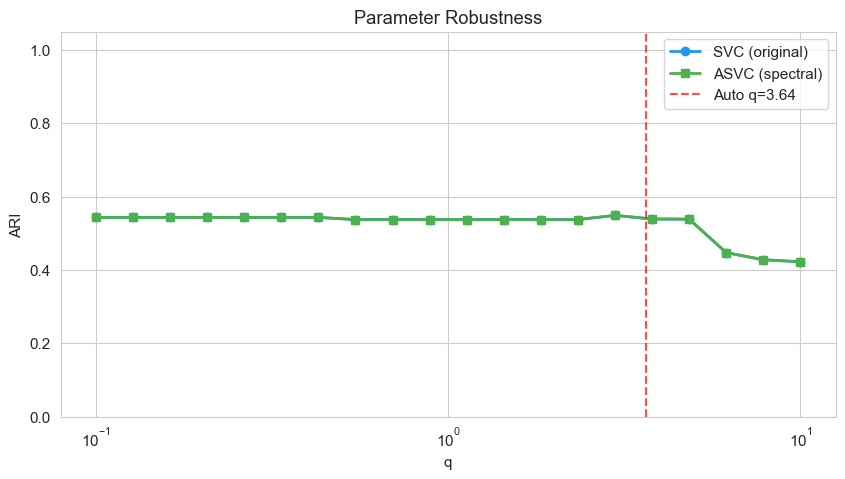

In [5]:
q_scan = np.logspace(-1, 1, 20)
s_ari, a_ari = [], []
for q in q_scan:
    svc = SVC(q=q, C=1.0, n_sample_points=30).fit(X_ir2d)
    s_ari.append(clustering_metrics(y_ir, svc.labels_)["ARI"])
    asvc = ASVC(nu=0.02, q=q, random_state=42).fit(X_ir2d)
    a_ari.append(clustering_metrics(y_ir, asvc.labels_)["ARI"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q_scan, s_ari, "o-", label="SVC (original)", color="#2196F3", lw=2)
ax.plot(q_scan, a_ari, "s-", label="ASVC (spectral)", color="#4CAF50", lw=2)
ax.axvline(asvc_full.q_used_, color="red", ls="--", alpha=0.7, label=f"Auto q={asvc_full.q_used_:.2f}")
ax.set_xscale("log"); ax.set_xlabel("q"); ax.set_ylabel("ARI")
ax.set_title("Parameter Robustness"); ax.legend(); ax.set_ylim(0, 1.05)
plt.savefig("../results/figures/parameter_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

## E5: High-Dimensional Robustness

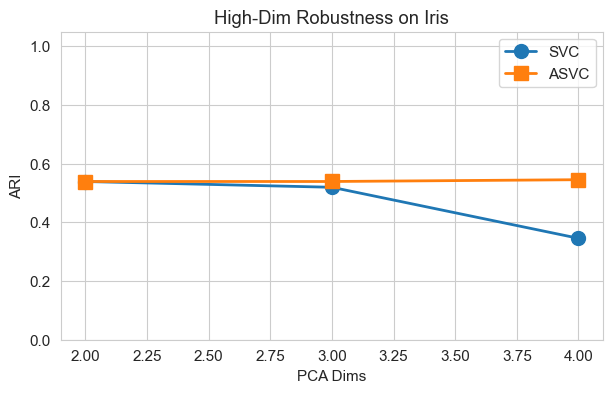

In [6]:
dims = [2, 3, 4]; svc_a, asvc_a = [], []
for d in dims:
    Xp = standardize(PCA(n_components=d).fit_transform(X_ir))
    svc = SVC(q=4.0, C=0.55, n_sample_points=30).fit(Xp)
    svc_a.append(clustering_metrics(y_ir, svc.labels_)["ARI"])
    asvc = ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit(Xp)
    asvc_a.append(clustering_metrics(y_ir, asvc.labels_)["ARI"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dims, svc_a, "o-", label="SVC", lw=2, ms=10); ax.plot(dims, asvc_a, "s-", label="ASVC", lw=2, ms=10)
ax.set_xlabel("PCA Dims"); ax.set_ylabel("ARI"); ax.set_title("High-Dim Robustness on Iris")
ax.legend(); ax.set_ylim(0, 1.05)
plt.savefig("../results/figures/highdim.png", dpi=150, bbox_inches="tight"); plt.show()


## E6: Runtime Comparison

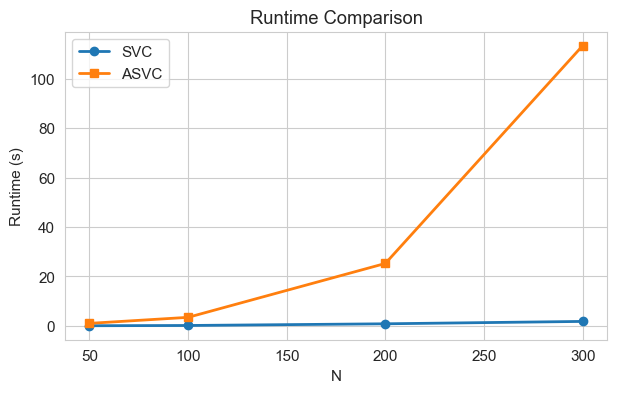

All experiments complete.


In [7]:
sizes = [50, 100, 200, 300]; svc_t, asvc_t = [], []
for n in sizes:
    Xs = standardize(make_blobs(n_samples=n, centers=2, cluster_std=1.0, random_state=42)[0])
    t0 = time.time(); SVC(q=2.0, C=1.0, n_sample_points=10).fit(Xs); svc_t.append(time.time()-t0)
    t0 = time.time(); ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit(Xs); asvc_t.append(time.time()-t0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, svc_t, "o-", label="SVC", lw=2); ax.plot(sizes, asvc_t, "s-", label="ASVC", lw=2)
ax.set_xlabel("N"); ax.set_ylabel("Runtime (s)"); ax.set_title("Runtime Comparison"); ax.legend()
plt.savefig("../results/figures/runtime.png", dpi=150, bbox_inches="tight"); plt.show()
print("All experiments complete.")
